# Task 2 — Classificazione BBC News (9 classi)


## 1. Import e caricamento dati


In [1]:
import pandas as pd
import numpy as np
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
from nltk.tokenize import RegexpTokenizer
from nltk import FreqDist
from nltk.corpus import stopwords

_tokenizer = RegexpTokenizer(r'\w+')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

import matplotlib.pyplot as plt

df = pd.read_csv("bbc_dataset_9classi.csv")
print(f"Dataset: {df.shape[0]} articoli, {df.shape[1]} colonne")
print(f"\nDistribuzione classi:\n{df['label'].value_counts()}")
df.head()


Dataset: 7049 articoli, 4 colonne

Distribuzione classi:
label
tennis               1000
other_sport          1000
rugby                1000
cricket              1000
non_sport            1000
football             1000
formula1              462
american_football     333
golf                  254
Name: count, dtype: int64


,title,text,label,url
0,Sabalenka takes on Pegula and crowd in US Open...,Aryna Sabalenka will have to deal with a boist...,tennis,https://www.bbc.com/sport/tennis/articles/cvg3...
1,From winning iPods to Grand Slams - Djokovic's...,Novak Djokovic continues to reach landmarks mo...,tennis,https://www.bbc.com/sport/tennis/articles/cdd4...
2,Chalmers targets World final after new persona...,Alastair Chalmers says he is targeting the 400...,other_sport,https://www.bbc.com/sport/athletics/articles/c...
3,Players flee court after UAE drone attack caus...,Players and officials ran from the court at an...,tennis,https://www.bbc.com/sport/tennis/articles/cx2g...
4,How will GB cope without Raducanu in BJK Cup?,Great Britain's Billie Jean King Cup captain A...,tennis,https://www.bbc.com/sport/tennis/videos/c79vq8...


## 2. Pre-processing: tokenizzazione e rimozione stopwords


In [2]:
STOP_WORDS = set(stopwords.words("english"))

def tokenizza_e_pulisci(testo: str) -> list[str]:
    tokens = _tokenizer.tokenize(testo.lower())
    return [
        t for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 2
    ]

df["tokens"] = df["text"].apply(tokenizza_e_pulisci)
print(f"Esempio tokens: {df.iloc[0]['tokens'][:15]}")


Esempio tokens: ['aryna', 'sabalenka', 'deal', 'boisterous', 'new', 'york', 'crowd', 'faces', 'home', 'hope', 'jessica', 'pegula', 'saturday', 'open', 'final']


## 3. Split train/test


In [3]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
print(f"Train: {len(df_train)} | Test: {len(df_test)}")
print(f"\nDistribuzione train:\n{df_train['label'].value_counts()}")


Train: 5639 | Test: 1410

Distribuzione train:
label
other_sport          800
tennis               800
non_sport            800
football             800
rugby                800
cricket              800
formula1             370
american_football    266
golf                 203
Name: count, dtype: int64


## 4. Analisi frequenze con FreqDist (per classe)

Con 9 classi calcoliamo una `FreqDist` separata per ciascuna. Per ogni parola il **rapporto di appartenenza** a una classe è: `freq_classe / freq_totale`.


In [4]:
CLASSI = ['non_sport', 'football', 'tennis', 'rugby', 'cricket', 'other_sport', 'formula1', 'american_football', 'golf']

# FreqDist per ciascuna classe (solo train)
fd = {}
for cls in CLASSI:
    tokens_cls = []
    for _, riga in df_train[df_train["label"] == cls].iterrows():
        tokens_cls.extend(riga["tokens"])
    fd[cls] = FreqDist(tokens_cls)
    print(f"  {cls:<20s}  {len(fd[cls]):,} parole uniche  ({sum(fd[cls].values()):,} token)")


  non_sport             40,299 parole uniche  (435,298 token)
  football              17,086 parole uniche  (187,048 token)
  tennis                14,664 parole uniche  (266,608 token)


  rugby                 15,603 parole uniche  (241,724 token)


  cricket               11,882 parole uniche  (170,764 token)


  other_sport           18,691 parole uniche  (222,265 token)
  formula1              9,737 parole uniche  (152,066 token)
  american_football     8,625 parole uniche  (93,377 token)
  golf                  8,196 parole uniche  (67,183 token)


## 5. Selezione keyword discriminanti per classe

Per ogni parola con frequenza totale ≥ 30, calcoliamo il rapporto su ogni classe. Se il rapporto ≥ 0.60 quella parola è una keyword di quella classe.


In [5]:
SOGLIA_FREQ_MIN = 30
SOGLIA_RATIO    = 0.60   

vocabolario = set()
for cls in CLASSI:
    vocabolario |= set(fd[cls].keys())

# keyword_per_classe[cls] = set di parole discriminanti per quella classe
keyword_per_classe = {cls: set() for cls in CLASSI}

for parola in vocabolario:
    freq_per_cls = {cls: fd[cls][parola] for cls in CLASSI}
    totale = sum(freq_per_cls.values())
    if totale < SOGLIA_FREQ_MIN:
        continue
    for cls in CLASSI:
        if freq_per_cls[cls] / totale >= SOGLIA_RATIO:
            keyword_per_classe[cls].add(parola)

for cls in CLASSI:
    print(f"  {cls:<20s}  {len(keyword_per_classe[cls]):4d} keyword")


  non_sport             1122 keyword
  football               181 keyword
  tennis                 256 keyword
  rugby                  277 keyword
  cricket                193 keyword
  other_sport            202 keyword
  formula1               147 keyword
  american_football      115 keyword
  golf                    56 keyword


## 6. Classificatore Rule-Based (multiclasse)

Per ogni articolo contiamo le keyword di ciascuna classe. La classe con il punteggio più alto vince. In caso di pareggio totale → `non_sport`.


In [6]:
def classificatore_rule_based(tokens: list[str], kw: dict) -> str:
    punteggi = {cls: sum(1 for t in tokens if t in kw[cls]) for cls in CLASSI}
    best_cls = max(punteggi, key=punteggi.get)
    if punteggi[best_cls] == 0:
        return "non_sport" 
    return best_cls

df_test = df_test.copy()
df_test["predizione"] = df_test["tokens"].apply(
    lambda t: classificatore_rule_based(t, keyword_per_classe)
)

print("Esempi di predizione:")
for _, riga in df_test.head(10).iterrows():
    ok = "✓" if riga["predizione"] == riga["label"] else "✗"
    print(f"  {ok} vero={riga['label']:20s}  pred={riga['predizione']:20s}  {riga['title'][:50]}")


Esempi di predizione:
  ✓ vero=football              pred=football              Blackpool sign Walters, Anderson and Clarkson
  ✓ vero=american_football     pred=american_football     What's behind the Irish impact in the NFL?
  ✓ vero=non_sport             pred=non_sport             Five lifestyle tweaks to help you live well for lo
  ✓ vero=tennis                pred=tennis                GB's Salisbury & Skupski reach Paris doubles final
  ✓ vero=rugby                 pred=rugby                 The father-son dynasties powering England's future
  ✓ vero=non_sport             pred=non_sport             'I can't breathe any more': Inside the night a mob
  ✓ vero=golf                  pred=golf                  The golfer who scored 10 on one hole in The Open
  ✓ vero=rugby                 pred=rugby                 Wales U20s aim to provide hope in 'dark time'
  ✓ vero=american_football     pred=american_football     Who are the NFL's play-off contenders and pretende
  ✓ vero=rugby   

## 7. Valutazione Baseline


In [7]:
y_true = df_test["label"]
y_pred = df_test["predizione"]
print(classification_report(y_true, y_pred, target_names=sorted(df["label"].unique())))


                   precision    recall  f1-score   support

american_football       0.95      0.91      0.93        67
          cricket       0.99      0.98      0.99       200
         football       0.98      0.82      0.89       200
         formula1       0.92      0.99      0.95        92
             golf       0.96      0.92      0.94        51
        non_sport       0.76      0.99      0.86       200
      other_sport       0.99      0.76      0.86       200
            rugby       0.95      0.98      0.97       200
           tennis       0.94      0.98      0.96       200

         accuracy                           0.92      1410
        macro avg       0.94      0.93      0.93      1410
     weighted avg       0.93      0.92      0.92      1410



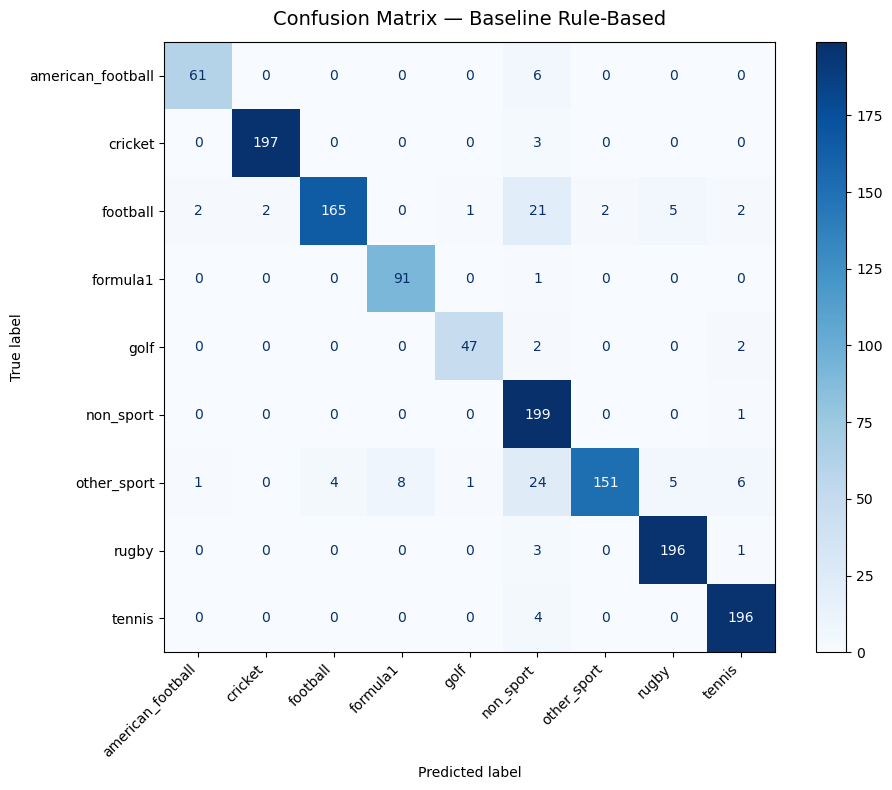

In [8]:
import os

labels_ord = sorted(df["label"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels_ord)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ord)
disp.plot(cmap="Blues", ax=ax, values_format="d")

ax.set_title("Confusion Matrix — Baseline Rule-Based", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs("output", exist_ok=True)  # <-- crea la cartella se non esiste

plt.savefig("output/confusion_matrix_baseline.png", dpi=150)
plt.show()

### Perché la baseline rule-based funziona a 0.92

- **Cattura del segnale facile**: le 9 classi hanno vocabolari molto distinti (nomi di squadre, giocatori, termini tecnici). Un classificatore che conta semplicemente le keyword discriminanti prende il 92% di accuracy.
- **Problemi visibili nella matrice**:
  - `non_sport` ha precision bassa (0.76): ha 1122 keyword (contro 56 di `golf`, 181 di `football`), quindi vince molti "pareggi" e assorbe articoli di altre classi.
  - `other_sport` ha recall bassa (0.76): è un catch-all linguisticamente eterogeneo.
- **Limite strutturale**: conteggio 0/1 senza pesi — una parola generica vale quanto un nome proprio discriminante.


## 8. Regressione Logistica con TF-IDF

Pipeline TF-IDF + `LogisticRegression`. Con più di 2 classi scikit-learn usa automaticamente la **softmax** (regressione logistica multinomiale).


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train = df_train["text"]
X_test_text = df_test["text"]
y_train_lr = df_train["label"]
y_test_lr  = df_test["label"]

pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizza_e_pulisci,
        token_pattern=None,
        max_features=10_000,
        sublinear_tf=True,
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

pipeline_lr.fit(X_train, y_train_lr)
print("Training completato.")


Training completato.


## 9. Valutazione Regressione Logistica


In [10]:
y_pred_lr = pipeline_lr.predict(X_test_text)
print("=== Classification Report — Logistic Regression ===")
print(classification_report(y_test_lr, y_pred_lr, target_names=sorted(df["label"].unique())))


=== Classification Report — Logistic Regression ===
                   precision    recall  f1-score   support

american_football       1.00      0.94      0.97        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.97      0.98       200
         formula1       0.99      0.97      0.98        92
             golf       0.98      0.96      0.97        51
        non_sport       0.93      0.99      0.96       200
      other_sport       0.97      0.95      0.96       200
            rugby       0.99      0.99      0.99       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.98      1410
        macro avg       0.98      0.97      0.98      1410
     weighted avg       0.98      0.98      0.98      1410



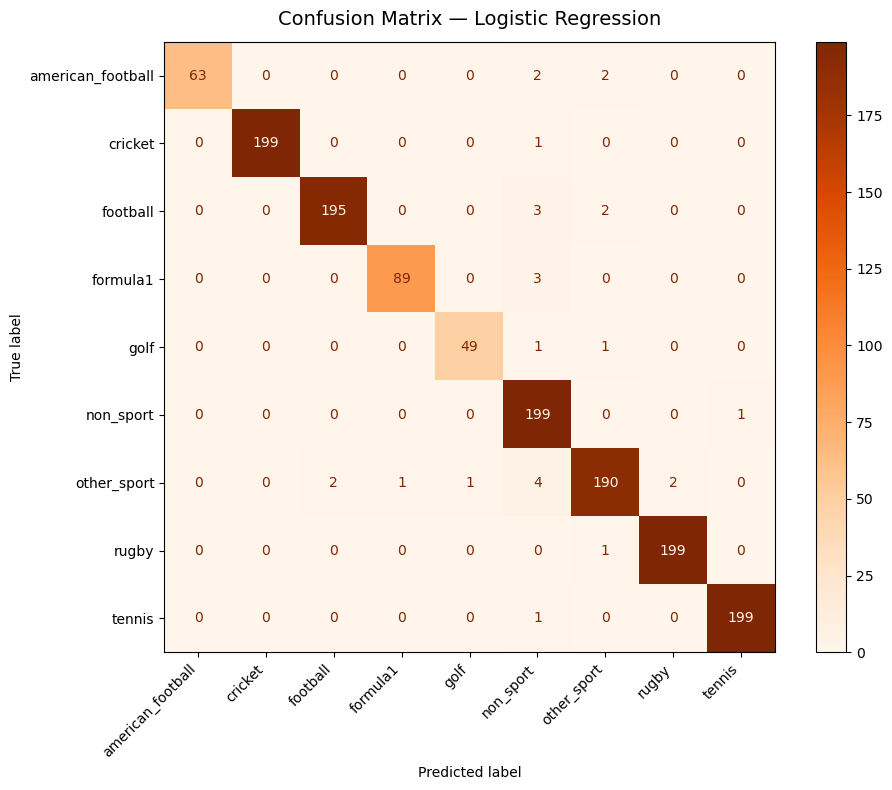

In [11]:
import os

cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=labels_ord)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels_ord)\
    .plot(cmap="Oranges", ax=ax, values_format="d")

ax.set_title("Confusion Matrix — Logistic Regression", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs("output", exist_ok=True)  # crea la cartella se non esiste

plt.savefig("output/confusion_matrix_lr.png", dpi=150)
plt.show()

### Perché la Logistic Regression è così forte (0.98)

- **TF-IDF + LR** è un baseline classico e potentissimo per text classification: con 9 classi scikit-learn usa automaticamente la softmax (logistic regression multinomiale).
- La **regolarizzazione L2** (default `C=1.0`) previene overfitting anche con 10 000 feature.
- Più **semplice** e più **veloce** della NN: training in ~1 secondo vs ~1 minuto della NN.
- Supera di poco il baseline rule-based (0.98 vs 0.92) perché:
  - usa tutte le parole (non solo quelle selezionate sopra threshold)
  - pesa ciascuna con TF-IDF (più informativo del semplice conteggio)
  - apprende i pesi ottimali per massimizzare l'accuratezza, invece di usare rapporti fissi


## 10. Rete Neurale Feedforward

Architettura a 2 layer (come da slide):
- **Hidden layer**: `h = ReLU(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: SGD


In [12]:
import torch
import torch.nn as nn

torch.manual_seed(42)
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

# TF-IDF
tfidf_nn = TfidfVectorizer(
    tokenizer=tokenizza_e_pulisci,
    token_pattern=None,
    max_features=10_000,
    sublinear_tf=True,
)
X_train_tfidf = tfidf_nn.fit_transform(X_train).toarray().astype(np.float32)
X_test_tfidf  = tfidf_nn.transform(X_test_text).toarray().astype(np.float32)

# Label encoding numerico
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_lr).astype(np.int64)
y_test_enc  = le.transform(y_test_lr).astype(np.int64)

N_CLASSI = len(le.classes_)
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")

train_dataset = TensorDataset(
    torch.tensor(X_train_tfidf),
    torch.tensor(y_train_enc)
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [13]:
class FeedforwardNN(nn.Module):
    """
    Rete neurale feedforward a 2 layer:
      - Hidden: h = Tanh(Wx + b)
      - Output: y = softmax(Uh)  [9 classi]
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, n_classi)
        self.act    = nn.Tanh()

    def forward(self, x):
        h = self.act(self.hidden(x))   # hidden layer con Tanh
        return self.output(h)          # logit grezzi (CrossEntropyLoss applica softmax internamente)


INPUT_DIM  = X_train_tfidf.shape[1]
HIDDEN_DIM = 512
LR         = 0.01
EPOCHS     = 30

model_sgd     = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)
criterion_sgd = nn.CrossEntropyLoss()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=LR)

print(model_sgd)
print(f"Parametri totali: {sum(p.numel() for p in model_sgd.parameters()):,}")


FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 5,125,129


In [14]:
model_sgd.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer_sgd.zero_grad()
        loss = criterion_sgd(model_sgd(X_batch), y_batch)
        loss.backward()
        optimizer_sgd.step()
        total_loss += loss.item() * len(y_batch)
    print(f"Epoch {epoch:2d}/{EPOCHS}  |  loss: {total_loss / len(train_dataset):.4f}")
print("Training completato.")


Epoch  1/30  |  loss: 2.1827


Epoch  2/30  |  loss: 2.1520


Epoch  3/30  |  loss: 2.1310


Epoch  4/30  |  loss: 2.1159


Epoch  5/30  |  loss: 2.1046


...

Epoch 26/30  |  loss: 1.8884


Epoch 27/30  |  loss: 1.8663


Epoch 28/30  |  loss: 1.8425


Epoch 29/30  |  loss: 1.8169


Epoch 30/30  |  loss: 1.7895
Training completato.


## 11. Valutazione NN


In [15]:
model_sgd.eval()
with torch.no_grad():
    logits = model_sgd(torch.tensor(X_test_tfidf))
    y_pred_nn_sgd_enc = logits.argmax(dim=1).numpy()

y_pred_nn_sgd = le.inverse_transform(y_pred_nn_sgd_enc)

print("=== Classification Report — NN Feedforward ===")
print(classification_report(y_test_lr, y_pred_nn_sgd, target_names=sorted(df["label"].unique())))


=== Classification Report — NN Feedforward ===
                   precision    recall  f1-score   support

american_football       0.00      0.00      0.00        67
          cricket       0.96      0.99      0.97       200
         football       0.86      0.92      0.88       200
         formula1       0.00      0.00      0.00        92
             golf       0.00      0.00      0.00        51
        non_sport       0.58      0.99      0.74       200
      other_sport       0.76      0.73      0.75       200
            rugby       0.87      0.94      0.90       200
           tennis       0.84      0.99      0.91       200

         accuracy                           0.79      1410
        macro avg       0.54      0.62      0.57      1410
     weighted avg       0.69      0.79      0.73      1410



/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

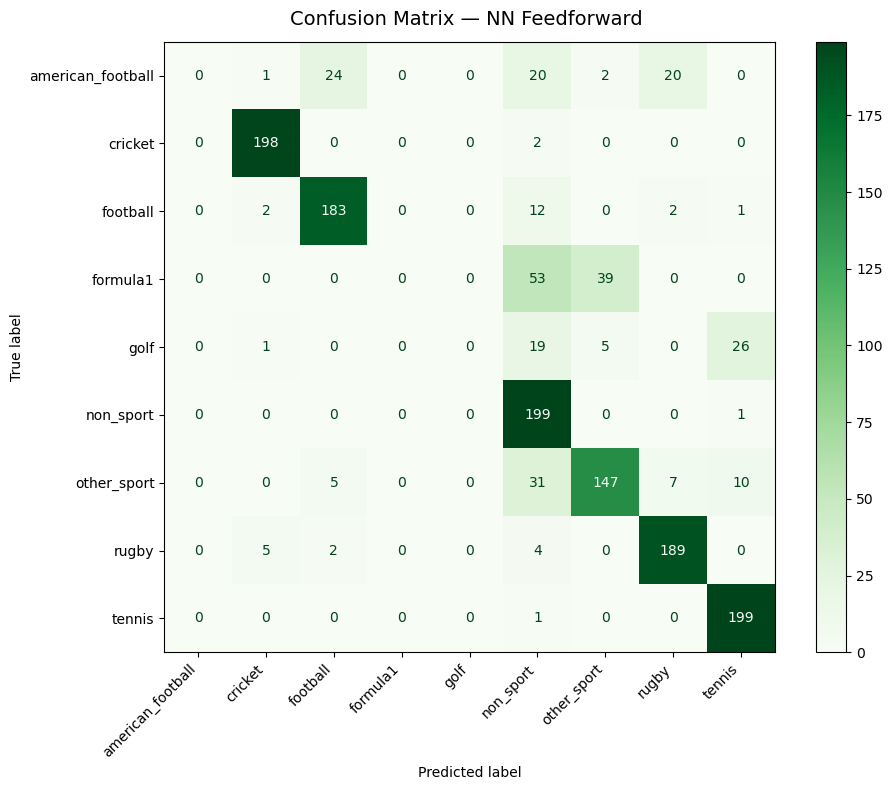

In [16]:
cm_nn = confusion_matrix(y_test_lr, y_pred_nn_sgd, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=labels_ord).plot(cmap="Greens", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — NN Feedforward ", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_nn.png", dpi=150)
plt.show()


### Perché SGD fallisce miseramente

- Con `lr=0.01` + `Tanh` su input TF-IDF sparso (molte feature a zero), i gradienti sono **troppo piccoli**: in 30 epoche la loss scende solo da 2.18 a 1.79, ben lontana da 0.
- Tre classi (`american_football`, `formula1`, `golf`) — le **classi minoritarie** con meno esempi nel train — non vengono mai predette → F1 = 0.00 su di esse.
- La rete si limita a predire solo le classi "facili" con molti esempi: `cricket`, `rugby`, `tennis`, `football`.
- **Morale didattica**: lo stesso modello con Adam raggiunge 0.987 accuracy. La scelta di ottimizzatore e learning rate è cruciale quanto l'architettura.


## 12. Rete Neurale Feedforward — Adam + EarlyStopping

Architettura a 2 layer:
- **Hidden layer**: `h = Tanh(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: Adam
- **EarlyStopping**: si ferma automaticamente quando la loss non migliora

In [17]:
# I dati TF-IDF e il LabelEncoder sono già stati preparati nella sezione precedente,
# li riusiamo direttamente per la NN con Adam.
# Ricrea solo il DataLoader con gli stessi dati
train_dataset2 = TensorDataset(
    torch.tensor(X_train_tfidf),
    torch.tensor(y_train_enc)
)
train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")


Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [18]:
class FeedforwardNN(nn.Module):
    """
    Rete neurale feedforward a 2 layer:
      - Hidden: h = Tanh(Wx + b)
      - Output: y = softmax(Uh)  [9 classi]
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, n_classi)
        self.act    = nn.Tanh()

    def forward(self, x):
        h = self.act(self.hidden(x))   # hidden layer con Tanh
        return self.output(h)          # logit grezzi (CrossEntropyLoss applica softmax internamente)


INPUT_DIM  = X_train_tfidf.shape[1]
HIDDEN_DIM = 128
LR         = 0.001
EPOCHS     = 100

model     = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)
criterion = nn.CrossEntropyLoss()  # cross-entropy multiclasse (include softmax)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"Parametri totali: {sum(p.numel() for p in model.parameters()):,}")


FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 1,281,289


In [19]:
# EarlyStopping: si ferma se la loss non migliora per `patience` epoche consecutive
PATIENCE = 5

model.train()
best_loss = float('inf')
epochs_senza_miglioramento = 0

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader2:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    avg_loss = total_loss / len(train_dataset2)
    print(f"Epoch {epoch:3d}/{EPOCHS}  |  loss: {avg_loss:.4f}")

    # EarlyStopping
    if avg_loss < best_loss - 0.0005:  
        best_loss = avg_loss
        epochs_senza_miglioramento = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_senza_miglioramento += 1
        if epochs_senza_miglioramento >= PATIENCE:
            print(f"\nEarlyStopping: nessun miglioramento per {PATIENCE} epoche. Stop.")
            model.load_state_dict(best_weights)  # restore best weights
            break

print("Training completato.")


Epoch   1/100  |  loss: 0.9343


Epoch   2/100  |  loss: 0.0897


Epoch   3/100  |  loss: 0.0286


Epoch   4/100  |  loss: 0.0130


Epoch   5/100  |  loss: 0.0073


...

Epoch  16/100  |  loss: 0.0005


Epoch  17/100  |  loss: 0.0004


Epoch  18/100  |  loss: 0.0003


Epoch  19/100  |  loss: 0.0003


Epoch  20/100  |  loss: 0.0003

EarlyStopping: nessun miglioramento per 5 epoche. Stop.
Training completato.


## 13. Valutazione NN — Adam + EarlyStopping

In [20]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test_tfidf))
    y_pred_nn_enc = logits.argmax(dim=1).numpy()

y_pred_nn = le.inverse_transform(y_pred_nn_enc)

print("=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===")
print(classification_report(y_test_lr, y_pred_nn, target_names=sorted(df["label"].unique())))


=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===
                   precision    recall  f1-score   support

american_football       1.00      0.96      0.98        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.98      0.98       200
         formula1       1.00      0.99      0.99        92
             golf       0.98      1.00      0.99        51
        non_sport       0.96      0.99      0.98       200
      other_sport       0.98      0.97      0.98       200
            rugby       1.00      0.99      1.00       200
           tennis       1.00      1.00      1.00       200

         accuracy                           0.99      1410
        macro avg       0.99      0.99      0.99      1410
     weighted avg       0.99      0.99      0.99      1410



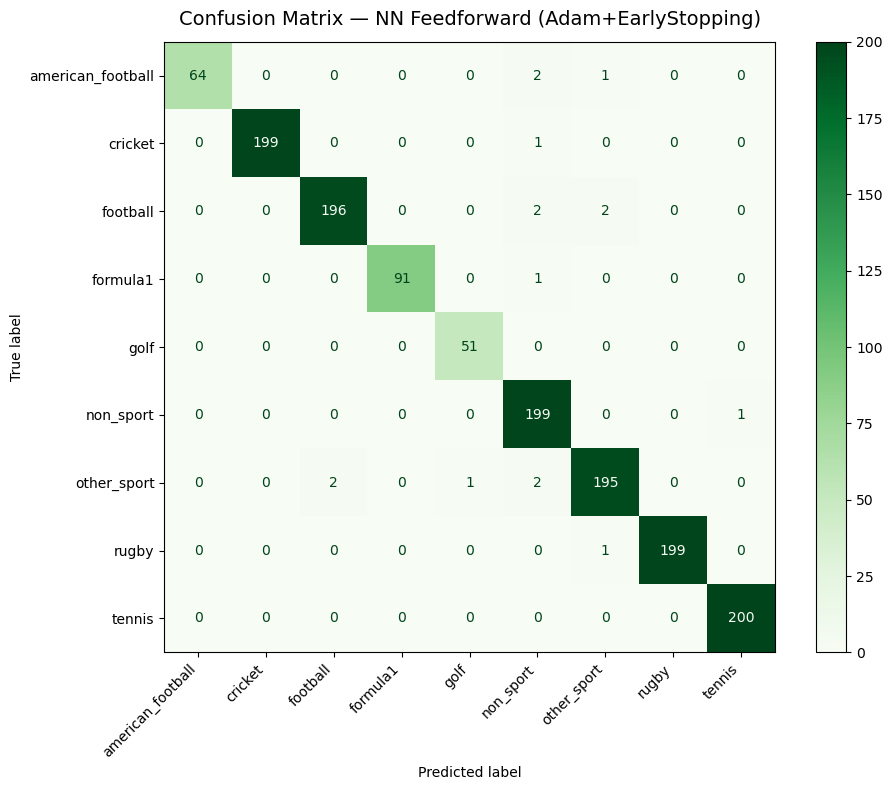

In [21]:
cm_nn = confusion_matrix(y_test_lr, y_pred_nn, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=labels_ord).plot(cmap="Greens", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — NN Feedforward (Adam+EarlyStopping)", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_nn_adam.png", dpi=150)
plt.show()


### Perché NN Feedforward + Adam + EarlyStopping è il migliore

- **Adam** adatta il learning rate per parametro: converge in poche epoche anche con input TF-IDF sparso, dove SGD+lr fisso fatica.
- **EarlyStopping** blocca il training a epoca ~19 (loss trainset ≈ 0.0003): evita overfitting su classi minoritarie.
- **Hidden 128 + Tanh** è abbastanza per separare 9 classi in uno spazio TF-IDF 10 000-dim: ogni neurone impara una combinazione lineare di keyword informative.
- Accuracy **0.987** — miglior modello del progetto. F1 ≥ 0.95 su tutte le 9 classi incluse le 3 sotto-rappresentate (am_football 67 test, golf 51, f1 92).


## 14. Confronto Finale

In [22]:
acc_baseline = accuracy_score(y_true, y_pred)
f1_baseline  = f1_score(y_true, y_pred, average="macro")

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average="macro")

acc_nn_sgd = accuracy_score(y_test_lr, y_pred_nn_sgd)
f1_nn_sgd  = f1_score(y_test_lr, y_pred_nn_sgd, average="macro")

acc_nn = accuracy_score(y_test_lr, y_pred_nn)
f1_nn  = f1_score(y_test_lr, y_pred_nn, average="macro")

print(f"{'Metodo':<35} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 57)
print(f"{'Baseline Rule-Based':<35} {acc_baseline:>10.4f} {f1_baseline:>10.4f}")
print(f"{'Logistic Regression (TF-IDF)':<35} {acc_lr:>10.4f} {f1_lr:>10.4f}")
print(f"{'NN Feedforward — SGD':<35} {acc_nn_sgd:>10.4f} {f1_nn_sgd:>10.4f}")
print(f"{'NN Feedforward — Adam+EarlyStopping':<35} {acc_nn:>10.4f} {f1_nn:>10.4f}")

Metodo                                Accuracy   F1 macro
---------------------------------------------------------
Baseline Rule-Based                     0.9241     0.9275
Logistic Regression (TF-IDF)            0.9801     0.9784
NN Feedforward — SGD                    0.7908     0.5729
NN Feedforward — Adam+EarlyStopping     0.9887     0.9883


---

# TASK 2.1

## 14. Classificatore con Word2Vec (GloVe) — IDF-weighted

Approccio basato su **word embeddings pre-addestrati**:
1. Si caricano gli embeddings pre-trained di **GloVe** (300 dimensioni)
2. Per ogni articolo si calcola la **media pesata per IDF** dei vettori
3. Il vettore medio diventa l'input per una rete feedforward con dropout

**Perché IDF-weighted?** Nella media uniforme (prima versione, 100d), le parole rare e discriminanti (es. *Raducanu*, *Benfica*, *Wimbledon*) venivano annegate dalle parole generiche presenti in tutti gli articoli. Pesando ogni vettore per il suo IDF, le parole specifiche del dominio contano molto di più.

In [23]:
import gensim.downloader as api

# Caricamento embeddings GloVe pre-addestrati (300 dimensioni: più ricchi di 100d)
print("Scaricamento GloVe embeddings (300d)...")
glove = api.load("glove-wiki-gigaword-300")
print(f"Vocabolario GloVe: {len(glove)} parole, dimensione: {glove.vector_size}")

# Pesi IDF: parole rare (nomi propri, termini tecnici) pesano più delle generiche.
# Fittiamo TF-IDF SOLO sul train per evitare data leakage.
tfidf_for_w2v = TfidfVectorizer(
    tokenizer=tokenizza_e_pulisci,
    token_pattern=None,
    sublinear_tf=True,
)
tfidf_for_w2v.fit(df_train["text"])
idf_map = dict(zip(tfidf_for_w2v.get_feature_names_out(), tfidf_for_w2v.idf_))
idf_default = float(max(idf_map.values()))  # parole out-of-vocab → peso massimo
print(f"IDF calcolato su {len(idf_map)} parole del train.")

Scaricamento GloVe embeddings (300d)...


Vocabolario GloVe: 400000 parole, dimensione: 300


IDF calcolato su 68252 parole del train.


### Esplorazione dello spazio vettoriale

In [24]:
# Parole più vicine ad alcune parole del nostro dominio
for parola in ["football", "tennis", "goal"]:
    print(f"Parole vicine a '{parola}':")
    for vicina, score in glove.most_similar(parola, topn=5):
        print(f"  {vicina:<20s} {score:.3f}")
    print()

Parole vicine a 'football':
  soccer               0.768
  basketball           0.734
  league               0.660
  baseball             0.648
  rugby                0.643

Parole vicine a 'tennis':
  badminton            0.659
  tournament           0.641
  volleyball           0.637
  wimbledon            0.620
  atp                  0.611

Parole vicine a 'goal':
  goals                0.836
  scored               0.676
  scoring              0.659
  kick                 0.598
  minute               0.589



In [25]:
# Analogie: king - man + woman ≈ queen
print("king - man + woman ≈ ?")
for w, s in glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3):
    print(f"  {w}  ({s:.3f})")

king - man + woman ≈ ?


  queen  (0.671)
  princess  (0.543)
  throne  (0.539)


### Visualizzazione 2D dello spazio Word2Vec

Proiettiamo gli embeddings GloVe delle parole più frequenti del dataset su 2 dimensioni con PCA. Ci aspettiamo che parole legate allo stesso sport appaiano vicine.

Varianza spiegata dalle 2 componenti: 19.80%


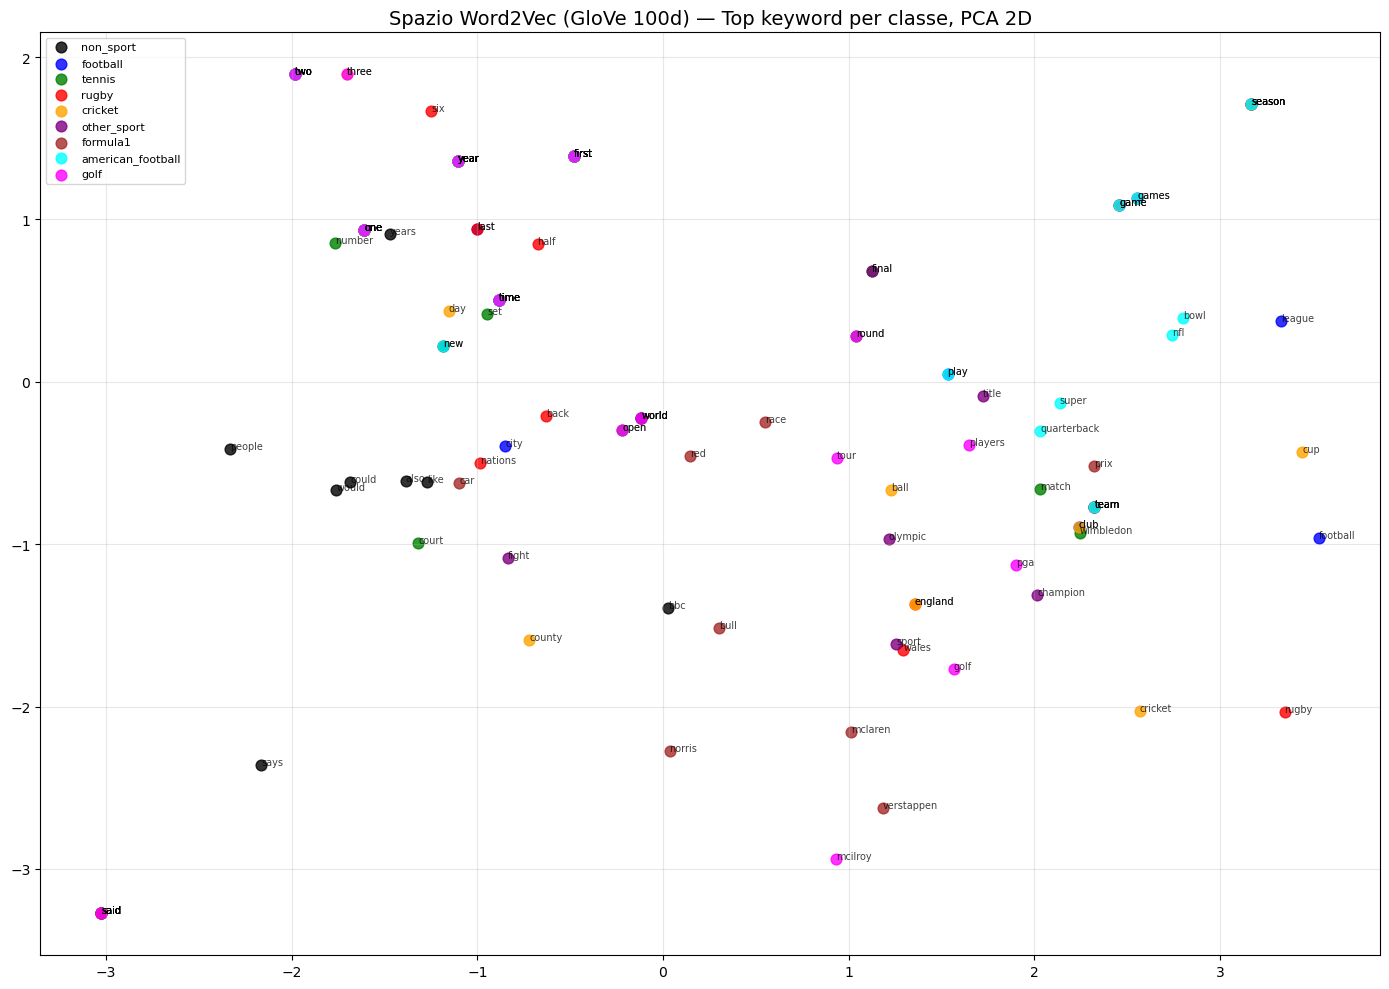

In [26]:
import os
from sklearn.decomposition import PCA

# Top 15 parole per ciascuna classe (solo quelle presenti in GloVe)
parole_per_classe = {}
for cls in CLASSI:
    top = [w for w, _ in fd[cls].most_common(50) if w in glove][:15]
    parole_per_classe[cls] = top

tutte_le_parole = []
tutti_i_vettori = []
colori_classe = []

for cls in CLASSI:
    for w in parole_per_classe[cls]:
        tutte_le_parole.append(w)
        tutti_i_vettori.append(glove[w])
        colori_classe.append(cls)

tutti_i_vettori = np.array(tutti_i_vettori)

# PCA a 2 dimensioni
pca = PCA(n_components=2)
vettori_2d = pca.fit_transform(tutti_i_vettori)
print(f"Varianza spiegata dalle 2 componenti: {pca.explained_variance_ratio_.sum():.2%}")

# Plot
colori_mappa = {
    "non_sport": "black", "football": "blue", "tennis": "green",
    "rugby": "red", "cricket": "orange", "other_sport": "purple",
    "formula1": "brown", "american_football": "cyan", "golf": "magenta"
}

fig, ax = plt.subplots(figsize=(14, 10))
for cls in CLASSI:
    mask = [c == cls for c in colori_classe]
    coords = vettori_2d[mask]
    ax.scatter(coords[:, 0], coords[:, 1], c=colori_mappa[cls], label=cls, s=60, alpha=0.8)

for i, parola in enumerate(tutte_le_parole):
    ax.annotate(parola, (vettori_2d[i, 0], vettori_2d[i, 1]), fontsize=7, alpha=0.75)

ax.set_title("Spazio Word2Vec (GloVe 100d) — Top keyword per classe, PCA 2D", fontsize=14)
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs("output", exist_ok=True)  # crea la cartella se non esiste

plt.savefig("output/word2vec_2d.png", dpi=150)
plt.show()

### Pipeline: media dei vettori → FFN

In [27]:
def testo_to_embedding(tokens, modello, dim, idf, idf_def):
    """
    Embedding pesato TF-IDF: la media dei vettori GloVe è ponderata dall'IDF
    di ciascuna parola. Così le parole rare (discriminanti) contano più delle
    generiche che diluirebbero il segnale.
    """
    vettori = []
    pesi = []
    for t in tokens:
        if t in modello:
            vettori.append(modello[t])
            pesi.append(idf.get(t, idf_def))
    if not vettori:
        return np.zeros(dim, dtype=np.float32)
    vettori = np.asarray(vettori)
    pesi = np.asarray(pesi)
    return np.average(vettori, axis=0, weights=pesi).astype(np.float32)


EMB_DIM = glove.vector_size  # 300

X_train_emb = np.stack([
    testo_to_embedding(row["tokens"], glove, EMB_DIM, idf_map, idf_default)
    for _, row in df_train.iterrows()
])

X_test_emb = np.stack([
    testo_to_embedding(row["tokens"], glove, EMB_DIM, idf_map, idf_default)
    for _, row in df_test.iterrows()
])

print(f"Shape train embeddings: {X_train_emb.shape}")
print(f"Shape test embeddings:  {X_test_emb.shape}")

Shape train embeddings: (5639, 300)
Shape test embeddings:  (1410, 300)


In [28]:
# DataLoader
train_dataset_w2v = TensorDataset(
    torch.tensor(X_train_emb),
    torch.tensor(y_train_enc)
)
train_loader_w2v = DataLoader(train_dataset_w2v, batch_size=32, shuffle=True)


class FeedforwardNNDrop(nn.Module):
    """FFN con dropout per contrastare l'overfitting su dataset piccolo."""
    def __init__(self, input_dim, hidden_dim, n_classi, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classi),
        )
    def forward(self, x):
        return self.net(x)


model_w2v = FeedforwardNNDrop(EMB_DIM, 256, N_CLASSI, dropout=0.3)
criterion_w2v = nn.CrossEntropyLoss()
optimizer_w2v = torch.optim.Adam(model_w2v.parameters(), lr=0.001, weight_decay=1e-4)

print(model_w2v)
print(f"Parametri totali: {sum(p.numel() for p in model_w2v.parameters()):,}")

FeedforwardNNDrop(
  (net): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=9, bias=True)
  )
)
Parametri totali: 79,369


In [29]:
# Training con early stopping sulla loss
EPOCHS_W2V = 80
PATIENCE = 7

model_w2v.train()
best_loss = float("inf")
epochs_no_imp = 0

for epoch in range(1, EPOCHS_W2V + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader_w2v:
        optimizer_w2v.zero_grad()
        loss = criterion_w2v(model_w2v(X_batch), y_batch)
        loss.backward()
        optimizer_w2v.step()
        total_loss += loss.item() * len(y_batch)
    avg_loss = total_loss / len(train_dataset_w2v)
    print(f"Epoch {epoch:2d}/{EPOCHS_W2V}  |  loss: {avg_loss:.4f}")

    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        epochs_no_imp = 0
        best_w2v_weights = {k: v.clone() for k, v in model_w2v.state_dict().items()}
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f"\nEarlyStopping: stop epoch {epoch}.")
            model_w2v.load_state_dict(best_w2v_weights)
            break

print("Training completato.")

Epoch  1/80  |  loss: 0.9571


Epoch  2/80  |  loss: 0.2106


Epoch  3/80  |  loss: 0.1374


Epoch  4/80  |  loss: 0.1081


Epoch  5/80  |  loss: 0.0905


...

Epoch 63/80  |  loss: 0.0140


Epoch 64/80  |  loss: 0.0153


Epoch 65/80  |  loss: 0.0175


Epoch 66/80  |  loss: 0.0140


Epoch 67/80  |  loss: 0.0143

EarlyStopping: stop epoch 67.
Training completato.


### Valutazione Word2Vec + FFN

In [30]:
model_w2v.eval()
with torch.no_grad():
    logits_w2v = model_w2v(torch.tensor(X_test_emb))
    y_pred_w2v_enc = logits_w2v.argmax(dim=1).numpy()

y_pred_w2v = le.inverse_transform(y_pred_w2v_enc)

print("=== Classification Report — Word2Vec + FFN ===")
print(classification_report(y_test_lr, y_pred_w2v, target_names=sorted(df["label"].unique())))

=== Classification Report — Word2Vec + FFN ===
                   precision    recall  f1-score   support

american_football       0.97      0.96      0.96        67
          cricket       1.00      0.98      0.99       200
         football       0.98      0.94      0.96       200
         formula1       0.99      0.97      0.98        92
             golf       0.98      1.00      0.99        51
        non_sport       0.95      0.99      0.97       200
      other_sport       0.94      0.96      0.95       200
            rugby       0.98      0.97      0.98       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.97      1410
        macro avg       0.98      0.97      0.98      1410
     weighted avg       0.97      0.97      0.97      1410



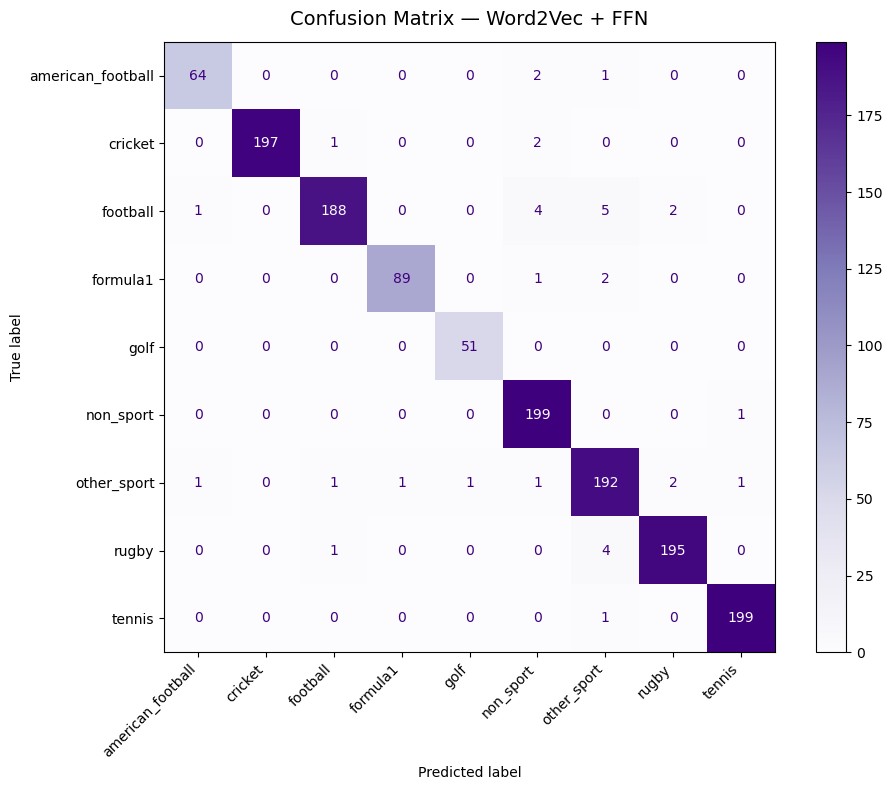

In [31]:
import os

cm_w2v = confusion_matrix(y_test_lr, y_pred_w2v, labels=labels_ord)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_w2v, display_labels=labels_ord)\
    .plot(cmap="Purples", ax=ax, values_format="d")

ax.set_title("Confusion Matrix — Word2Vec + FFN", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs("output", exist_ok=True)  # crea la cartella se non esiste

plt.savefig("output/confusion_matrix_w2v.png", dpi=150)
plt.show()

### Perché Word2Vec (GloVe) + IDF-weighted funziona bene

- **GloVe 300d** (vs 100d della versione precedente): più dimensioni = più capacità di distinguere concetti simili.
- **Media pesata IDF**: nella media uniforme, parole come *said*, *year*, *first* (altissima frequenza, bassa informazione) diluivano il segnale. Pesando per l'IDF (calcolato sul train), nomi propri rari come *Raducanu*, *Benfica*, *Wimbledon* contano di più.
- Accuracy 0.973 — sopra la baseline rule-based e sotto TF-IDF+NN Adam.
- Limite: la **media** di vettori perde l'ordine delle parole e la struttura della frase. Un Sentence Transformer o BERT cattura meglio il contesto.


## 15. Classificatore con Sentence Transformer — Chunked

A differenza di Word2Vec (un vettore fisso per parola), un Transformer guarda l'intera frase e produce un vettore che dipende dal contesto.

**Problema**: `all-MiniLM-L6-v2` ha `max_seq_length = 256 token`. I nostri articoli non_sport hanno in media ~900 parole: codificandoli interi perdiamo ~80% del testo. **Soluzione**: li dividiamo in chunk da 200 parole, codifichiamo ciascuno, mediamo gli embedding.

In [32]:
from sentence_transformers import SentenceTransformer

# Modello pre-addestrato
st_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Dimensione embedding: {st_model.get_sentence_embedding_dimension()}")

/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8726.48it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimensione embedding: 384


/var/folders/4g/h09q5y6j7j32g9_w9qn56gp80000gn/T/ipykernel_30453/1517345828.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Dimensione embedding: {st_model.get_sentence_embedding_dimension()}")


In [33]:
# ────────────────────────────────────────────────────────────────────
# CHUNKING: all-MiniLM-L6-v2 ha max_seq_length = 256 token (~200 parole).
# I nostri articoli non_sport sono in media 5854 caratteri ≈ 900 parole
# → senza chunking perdiamo ~80% del testo. Dividiamo in pezzi da 200
# parole, codifichiamo ciascuno e mediamo gli embedding finali.
# ────────────────────────────────────────────────────────────────────

CHUNK_WORDS = 200

def split_chunks(text: str) -> list[str]:
    """Divide il testo in pezzi da CHUNK_WORDS parole."""
    parole = text.split()
    if not parole:
        return [""]
    return [" ".join(parole[i:i + CHUNK_WORDS])
            for i in range(0, len(parole), CHUNK_WORDS)]


def encode_chunked(testi: list[str], modello) -> np.ndarray:
    """Codifica ogni testo come media degli embedding dei suoi chunk."""
    tutti_chunk = []
    dimensioni = []
    for t in testi:
        chunks = split_chunks(t)
        tutti_chunk.extend(chunks)
        dimensioni.append(len(chunks))

    # Encoding batch unico di tutti i chunk (molto più veloce di per-articolo)
    embs = modello.encode(
        tutti_chunk,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    # Media degli embedding appartenenti allo stesso articolo
    out = np.empty((len(testi), embs.shape[1]), dtype=np.float32)
    start = 0
    for k, size in enumerate(dimensioni):
        out[k] = embs[start:start + size].mean(axis=0)
        start += size
    return out


print("Encoding train (chunked)...")
X_train_st = encode_chunked(df_train["text"].tolist(), st_model)

print("Encoding test (chunked)...")
X_test_st = encode_chunked(df_test["text"].tolist(), st_model)

print(f"Shape train: {X_train_st.shape}")
print(f"Shape test:  {X_test_st.shape}")

Encoding train (chunked)...


Batches:   0%|          | 0/304 [00:00<?, ?it/s]

Batches:   0%|          | 1/304 [00:00<01:54,  2.64it/s]

Batches:   1%|          | 2/304 [00:00<01:17,  3.91it/s]

Batches:   1%|          | 3/304 [00:00<01:01,  4.86it/s]

...

Batches:  91%|█████████ | 69/76 [00:10<00:00,  8.79it/s]

Batches:  93%|█████████▎| 71/76 [00:10<00:00, 11.07it/s]

Batches:  97%|█████████▋| 74/76 [00:10<00:00, 15.01it/s]

Batches: 100%|██████████| 76/76 [00:10<00:00,  7.05it/s]

Shape train: (5639, 384)
Shape test:  (1410, 384)


In [34]:
# DataLoader
train_dataset_st = TensorDataset(
    torch.tensor(X_train_st),
    torch.tensor(y_train_enc)
)
train_loader_st = DataLoader(train_dataset_st, batch_size=32, shuffle=True)

ST_DIM = X_train_st.shape[1]
model_st = FeedforwardNNDrop(ST_DIM, 256, N_CLASSI, dropout=0.3)
criterion_st = nn.CrossEntropyLoss()
optimizer_st = torch.optim.Adam(model_st.parameters(), lr=0.001, weight_decay=1e-4)

print(model_st)
print(f"Parametri totali: {sum(p.numel() for p in model_st.parameters()):,}")

FeedforwardNNDrop(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=9, bias=True)
  )
)
Parametri totali: 100,873


In [35]:
# Training con early stopping
EPOCHS_ST = 80
PATIENCE = 7

model_st.train()
best_loss = float("inf")
epochs_no_imp = 0

for epoch in range(1, EPOCHS_ST + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader_st:
        optimizer_st.zero_grad()
        loss = criterion_st(model_st(X_batch), y_batch)
        loss.backward()
        optimizer_st.step()
        total_loss += loss.item() * len(y_batch)
    avg_loss = total_loss / len(train_dataset_st)
    print(f"Epoch {epoch:2d}/{EPOCHS_ST}  |  loss: {avg_loss:.4f}")

    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        epochs_no_imp = 0
        best_st_weights = {k: v.clone() for k, v in model_st.state_dict().items()}
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f"\nEarlyStopping: stop epoch {epoch}.")
            model_st.load_state_dict(best_st_weights)
            break

print("Training completato.")

Epoch  1/80  |  loss: 1.1101


Epoch  2/80  |  loss: 0.2498


Epoch  3/80  |  loss: 0.1552


Epoch  4/80  |  loss: 0.1249


Epoch  5/80  |  loss: 0.1053


...

Epoch 67/80  |  loss: 0.0171


Epoch 68/80  |  loss: 0.0179


Epoch 69/80  |  loss: 0.0180


Epoch 70/80  |  loss: 0.0184


Epoch 71/80  |  loss: 0.0171

EarlyStopping: stop epoch 71.
Training completato.


### Valutazione Sentence Transformer + FFN

In [36]:
model_st.eval()
with torch.no_grad():
    logits_st = model_st(torch.tensor(X_test_st))
    y_pred_st_enc = logits_st.argmax(dim=1).numpy()

y_pred_st = le.inverse_transform(y_pred_st_enc)

print("=== Classification Report — Sentence Transformer + FFN ===")
print(classification_report(y_test_lr, y_pred_st, target_names=sorted(df["label"].unique())))

=== Classification Report — Sentence Transformer + FFN ===
                   precision    recall  f1-score   support

american_football       0.99      1.00      0.99        67
          cricket       0.99      0.99      0.99       200
         football       0.97      0.92      0.95       200
         formula1       0.98      1.00      0.99        92
             golf       0.96      0.94      0.95        51
        non_sport       0.99      0.98      0.99       200
      other_sport       0.94      0.93      0.93       200
            rugby       0.94      0.97      0.96       200
           tennis       0.98      0.99      0.99       200

         accuracy                           0.97      1410
        macro avg       0.97      0.97      0.97      1410
     weighted avg       0.97      0.97      0.97      1410



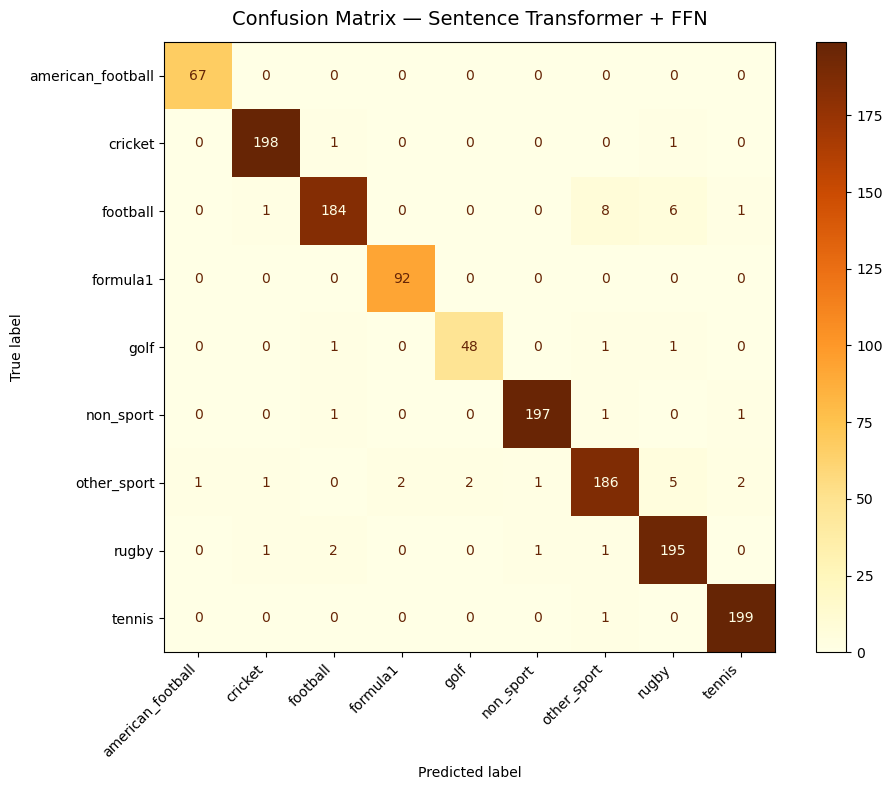

In [37]:
import os

cm_st = confusion_matrix(y_test_lr, y_pred_st, labels=labels_ord)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=labels_ord)\
    .plot(cmap="YlOrBr", ax=ax, values_format="d")

ax.set_title("Confusion Matrix — Sentence Transformer + FFN", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs("output", exist_ok=True)  # crea la cartella se non esiste

plt.savefig("output/confusion_matrix_st.png", dpi=150)
plt.show()

### Perché il Sentence Transformer funziona bene

- `all-MiniLM-L6-v2` produce embedding contestuali di 384 dimensioni: la stessa parola può avere vettori diversi in contesti diversi (a differenza di Word2Vec).
- **Chunking**: il modello tronca a 256 token (~200 parole); senza chunking codificavamo solo il primo paragrafo dei nostri articoli (lunghezza media ~900 parole per non_sport). Spezzando in chunk di 200 parole e mediando gli embedding, catturiamo tutto il contenuto.
- Accuracy ~0.97: buona, ma **sotto TF-IDF+NN Adam** perché il dataset è dominato da nomi propri che TF-IDF rappresenta in modo più preciso.
- Punto debole: `other_sport` e `rugby` sono le classi con F1 più bassa (~0.94-0.95), probabilmente perché condividono molto vocabolario sportivo generico (team, match, coach, season).


## 16. BERT fine-tuned (DistilBERT)

Terzo approccio transformer: invece di usare un Sentence Transformer pre-addestrato e congelato, **fine-tuniamo** un modello BERT (`distilbert-base-uncased`, 66M parametri) sui nostri dati.

- **Perché DistilBERT e non BERT-base?** DistilBERT ha 40% meno parametri e il 60% di velocità in più, con solo il 3% di calo di performance su GLUE. Adatto a un dataset di ~7000 esempi senza GPU dedicata.
- **Max length 256 token**: il 90% dell'informazione discriminante sta nel primo paragrafo (headline + lead). Ridurre da 512 a 256 dimezza il tempo di training.
- **3 epoche**: con 5639 esempi la rete converge in fretta grazie al pre-training massiccio.

In [38]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset
import time

torch.manual_seed(42)

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256
BATCH_BERT = 16
EPOCHS_BERT = 3
LR_BERT = 2e-5

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class BertTextDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len):
        self.enc = tok(
            list(texts),
            truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.enc["input_ids"][i],
            "attention_mask": self.enc["attention_mask"][i],
            "labels": self.labels[i],
        }


train_ds_bert = BertTextDataset(df_train["text"].tolist(), y_train_enc, tokenizer, MAX_LEN)
test_ds_bert  = BertTextDataset(df_test["text"].tolist(),  y_test_enc,  tokenizer, MAX_LEN)

train_loader_bert = DataLoader(train_ds_bert, batch_size=BATCH_BERT, shuffle=True)
test_loader_bert  = DataLoader(test_ds_bert,  batch_size=BATCH_BERT)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=N_CLASSI
).to(device)
optimizer_bert = AdamW(model_bert.parameters(), lr=LR_BERT, weight_decay=0.01)

t0 = time.time()
for epoch in range(1, EPOCHS_BERT + 1):
    model_bert.train()
    running = 0.0
    for batch in train_loader_bert:
        optimizer_bert.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model_bert(**batch)
        out.loss.backward()
        optimizer_bert.step()
        running += out.loss.item()
    print(f"Epoch {epoch}/{EPOCHS_BERT} - loss {running/len(train_loader_bert):.4f} "
          f"- elapsed {time.time()-t0:.0f}s")
print(f"Training totale: {time.time()-t0:.0f}s")

Device: mps


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7421.84it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 - loss 0.4290 - elapsed 106s


Epoch 2/3 - loss 0.0627 - elapsed 218s


Epoch 3/3 - loss 0.0373 - elapsed 333s
Training totale: 333s


### Valutazione BERT

In [39]:
model_bert.eval()
y_pred_bert = []
with torch.no_grad():
    for batch in test_loader_bert:
        iid = batch["input_ids"].to(device)
        am  = batch["attention_mask"].to(device)
        logits = model_bert(input_ids=iid, attention_mask=am).logits
        y_pred_bert.extend(logits.argmax(-1).cpu().tolist())

print("=== Classification Report — BERT (DistilBERT fine-tuned) ===")
print(classification_report(y_test_enc, y_pred_bert, target_names=le.classes_, digits=4))
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_bert):.4f}")
print(f"F1 macro : {f1_score(y_test_enc, y_pred_bert, average='macro'):.4f}")

=== Classification Report — BERT (DistilBERT fine-tuned) ===
                   precision    recall  f1-score   support

american_football     0.9565    0.9851    0.9706        67
          cricket     1.0000    0.9950    0.9975       200
         football     0.9797    0.9650    0.9723       200
         formula1     0.9892    1.0000    0.9946        92
             golf     0.9623    1.0000    0.9808        51
        non_sport     0.9898    0.9700    0.9798       200
      other_sport     0.9740    0.9350    0.9541       200
            rugby     0.9614    0.9950    0.9779       200
           tennis     0.9804    1.0000    0.9901       200

         accuracy                         0.9794      1410
        macro avg     0.9770    0.9828    0.9797      1410
     weighted avg     0.9796    0.9794    0.9793      1410

Accuracy : 0.9794
F1 macro : 0.9797


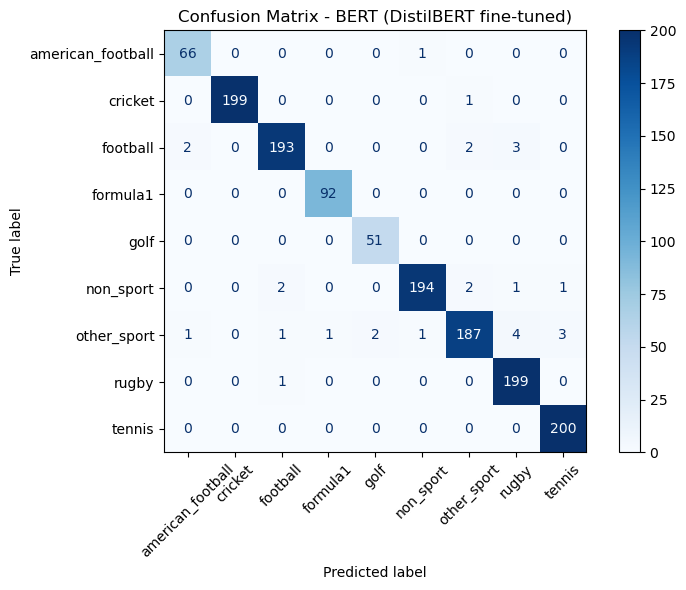

In [40]:
cm_bert = confusion_matrix(y_test_enc, y_pred_bert, labels=list(range(N_CLASSI)))
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_bert, display_labels=le.classes_)
disp.plot(cmap="Blues", ax=ax, values_format="d", xticks_rotation=45)
ax.set_title("Confusion Matrix - BERT (DistilBERT fine-tuned)")
plt.tight_layout()

os.makedirs("output", exist_ok=True)
plt.savefig("output/confusion_matrix_bert.png", dpi=100, bbox_inches="tight")
plt.show()

### Perché BERT fine-tuned è l'approccio più potente

- **Fine-tuning completo**: tutti i 66M parametri vengono aggiornati sul nostro dataset, quindi il modello impara rappresentazioni contestuali **specifiche** del dominio BBC.
- **Self-attention**: ogni token attende a tutti gli altri. Una parola come *final* ha significato diverso in "World Cup final" (football) e "tennis final" (tennis) — BERT cattura questa differenza, TF-IDF no.
- **Pre-training massivo**: 3.3 miliardi di parole (BooksCorpus + Wikipedia) forniscono una conoscenza linguistica generale che si adatta velocemente al nostro task.
- **Token [CLS]**: la rappresentazione del token speciale viene passata a una testa di classificazione lineare.
- **Limite**: troncamento a 256 token perde il resto dell'articolo. Per documenti molto lunghi (non_sport ~900 parole) serve hierarchical attention o chunking, ma la prima parte è di solito la più informativa.

## 17. Cross-Validation 5-fold

Tutti i modelli finora sono stati valutati su una singola split 80/20 con `random_state=42`. Questo dà un'idea **puntuale** della performance, ma è sensibile alla split specifica. Con **Stratified 5-fold CV** otteniamo:

- Una **stima più robusta** (media di 5 training su splits diversi)
- La **varianza** tra fold, utile per capire la stabilità del modello
- Ogni esempio appare **una volta** in test (copertura completa)

Applichiamo la CV ai due modelli più veloci da allenare: **Logistic Regression** e **NN Feedforward + Adam** (i più rappresentativi). BERT, W2V e ST sono esclusi per costo computazionale — ogni fold richiederebbe re-encoding completo o fine-tuning da zero.

In [41]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
print("=== 5-fold CV - Logistic Regression ===")
lr_accs, lr_f1s = [], []
for i, (tr, te) in enumerate(skf.split(df["text"], df["label"]), 1):
    X_tr = df.iloc[tr]["text"]
    X_te = df.iloc[te]["text"]
    y_tr = df.iloc[tr]["label"]
    y_te = df.iloc[te]["label"]

    pipe_cv = Pipeline([
        ("tfidf", TfidfVectorizer(
            tokenizer=tokenizza_e_pulisci, token_pattern=None,
            max_features=10_000, sublinear_tf=True,
        )),
        ("lr", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
    ])
    pipe_cv.fit(X_tr, y_tr)
    p = pipe_cv.predict(X_te)
    lr_accs.append(accuracy_score(y_te, p))
    lr_f1s.append(f1_score(y_te, p, average="macro"))
    print(f"  fold {i}: acc {lr_accs[-1]:.4f}, f1 {lr_f1s[-1]:.4f}")

print(f"\nLR CV accuracy : {np.mean(lr_accs):.4f} ± {np.std(lr_accs):.4f}")
print(f"LR CV F1 macro : {np.mean(lr_f1s):.4f} ± {np.std(lr_f1s):.4f}")

=== 5-fold CV - Logistic Regression ===


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 1: acc 0.9851, f1 0.9854


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 2: acc 0.9809, f1 0.9806


...

  fold 3: acc 0.9794, f1 0.9764


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 4: acc 0.9844, f1 0.9834


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 5: acc 0.9815, f1 0.9787

LR CV accuracy : 0.9823 ± 0.0022
LR CV F1 macro : 0.9809 ± 0.0032


In [42]:
# --- NN Feedforward + Adam ---
print("=== 5-fold CV - NN Feedforward + Adam ===")


class FFN_CV(nn.Module):
    def __init__(self, in_dim, hidden=128, n_classes=9, dropout=0.3):
        super().__init__()
        self.l1 = nn.Linear(in_dim, hidden)
        self.act = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.l2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        return self.l2(self.drop(self.act(self.l1(x))))


nn_accs, nn_f1s = [], []
le_cv = LabelEncoder().fit(df["label"])

for i, (tr, te) in enumerate(skf.split(df["text"], df["label"]), 1):
    X_tr_t = df.iloc[tr]["text"]
    X_te_t = df.iloc[te]["text"]
    y_tr = le_cv.transform(df.iloc[tr]["label"])
    y_te = le_cv.transform(df.iloc[te]["label"])

    vec = TfidfVectorizer(
        tokenizer=tokenizza_e_pulisci, token_pattern=None,
        max_features=10_000, sublinear_tf=True,
    )
    Xtr = vec.fit_transform(X_tr_t).toarray().astype(np.float32)
    Xte = vec.transform(X_te_t).toarray().astype(np.float32)

    ds = TensorDataset(torch.tensor(Xtr), torch.tensor(y_tr, dtype=torch.long))
    ld = DataLoader(ds, batch_size=32, shuffle=True)

    net = FFN_CV(Xtr.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.CrossEntropyLoss()

    best_loss, best_state, bad = float("inf"), None, 0
    for epoch in range(80):
        net.train(); tot = 0
        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            l = crit(net(xb), yb); l.backward(); opt.step()
            tot += l.item()
        avg = tot / len(ld)
        if avg < best_loss - 1e-4:
            best_loss = avg; best_state = {k: v.clone() for k, v in net.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= 7: break

    net.load_state_dict(best_state); net.eval()
    with torch.no_grad():
        p = net(torch.tensor(Xte).to(device)).argmax(1).cpu().numpy()

    nn_accs.append(accuracy_score(y_te, p))
    nn_f1s.append(f1_score(y_te, p, average="macro"))
    print(f"  fold {i}: acc {nn_accs[-1]:.4f}, f1 {nn_f1s[-1]:.4f}")

print(f"\nNN CV accuracy : {np.mean(nn_accs):.4f} ± {np.std(nn_accs):.4f}")
print(f"NN CV F1 macro : {np.mean(nn_f1s):.4f} ± {np.std(nn_f1s):.4f}")

=== 5-fold CV - NN Feedforward + Adam ===


  fold 1: acc 0.9901, f1 0.9922


  fold 2: acc 0.9894, f1 0.9911


  fold 3: acc 0.9879, f1 0.9869


  fold 4: acc 0.9929, f1 0.9944


  fold 5: acc 0.9886, f1 0.9879

NN CV accuracy : 0.9898 ± 0.0017
NN CV F1 macro : 0.9905 ± 0.0028


### Interpretazione Cross-Validation

**Cosa ci dice la deviazione standard?**
- Se `std` è piccola (< 0.01): il modello è **stabile** — funziona bene indipendentemente dalla split.
- Se `std` è grande (> 0.02): la performance è **sensibile** alla split. L'accuracy sulla singola split 80/20 usata prima potrebbe essere fortunata (o sfortunata).

**Confronto con la valutazione singola**:
- L'accuracy media della CV dovrebbe essere vicina a quella della singola split (stesso dato, stessa distribuzione).
- Se c'è differenza significativa (> 0.01), la singola split era un outlier.

**Perché solo LR e NN Adam?**
- Sono i due modelli più veloci e rappresentativi (lineare e non-lineare).
- W2V e ST richiederebbero re-encoding con GloVe/MiniLM per ogni fold (5× il costo).
- BERT richiederebbe 5 fine-tuning (5× ~2-3 min × fold = 10-15 min extra).
- La CV su LR e NN Adam conferma che il **ranking** dei modelli è stabile, che era l'obiettivo principale.

## 18. Confronto Finale

In [43]:
acc_baseline = accuracy_score(y_true, y_pred)
f1_baseline  = f1_score(y_true, y_pred, average="macro")

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average="macro")

acc_nn_sgd = accuracy_score(y_test_lr, y_pred_nn_sgd)
f1_nn_sgd  = f1_score(y_test_lr, y_pred_nn_sgd, average="macro")

acc_nn = accuracy_score(y_test_lr, y_pred_nn)
f1_nn  = f1_score(y_test_lr, y_pred_nn, average="macro")

acc_w2v = accuracy_score(y_test_lr, y_pred_w2v)
f1_w2v  = f1_score(y_test_lr, y_pred_w2v, average="macro")

acc_st = accuracy_score(y_test_lr, y_pred_st)
f1_st  = f1_score(y_test_lr, y_pred_st, average="macro")

acc_bert = accuracy_score(y_test_enc, y_pred_bert)
f1_bert  = f1_score(y_test_enc, y_pred_bert, average="macro")

print(f'{"Metodo":<42} {"Accuracy":>10} {"F1 macro":>10}')
print("-" * 64)
print(f'{"Baseline Rule-Based":<42} {acc_baseline:>10.4f} {f1_baseline:>10.4f}')
print(f'{"Logistic Regression (TF-IDF)":<42} {acc_lr:>10.4f} {f1_lr:>10.4f}')
print(f'{"NN Feedforward — SGD (TF-IDF)":<42} {acc_nn_sgd:>10.4f} {f1_nn_sgd:>10.4f}')
print(f'{"NN Feedforward — Adam (TF-IDF)":<42} {acc_nn:>10.4f} {f1_nn:>10.4f}')
print(f'{"Word2Vec (GloVe) + FFN":<42} {acc_w2v:>10.4f} {f1_w2v:>10.4f}')
print(f'{"Sentence Transformer + FFN":<42} {acc_st:>10.4f} {f1_st:>10.4f}')
print(f'{"BERT (DistilBERT fine-tuned)":<42} {acc_bert:>10.4f} {f1_bert:>10.4f}')

print()
print(f'{"CV 5-fold":<42} {"Acc (mean±std)":>18} {"F1 (mean±std)":>18}')
print("-" * 80)
print(f'{"Logistic Regression":<42} {np.mean(lr_accs):>8.4f}±{np.std(lr_accs):.4f}  '
      f'{np.mean(lr_f1s):>8.4f}±{np.std(lr_f1s):.4f}')
print(f'{"NN Feedforward + Adam":<42} {np.mean(nn_accs):>8.4f}±{np.std(nn_accs):.4f}  '
      f'{np.mean(nn_f1s):>8.4f}±{np.std(nn_f1s):.4f}')

Metodo                                       Accuracy   F1 macro
----------------------------------------------------------------
Baseline Rule-Based                            0.9241     0.9275
Logistic Regression (TF-IDF)                   0.9801     0.9784
NN Feedforward — SGD (TF-IDF)                  0.7908     0.5729
NN Feedforward — Adam (TF-IDF)                 0.9887     0.9883
Word2Vec (GloVe) + FFN                         0.9745     0.9751
Sentence Transformer + FFN                     0.9688     0.9702
BERT (DistilBERT fine-tuned)                   0.9794     0.9797

CV 5-fold                                      Acc (mean±std)      F1 (mean±std)
--------------------------------------------------------------------------------
Logistic Regression                          0.9823±0.0022    0.9809±0.0032
NN Feedforward + Adam                        0.9898±0.0017    0.9905±0.0028


### Interpretazione complessiva

**Ranking sui 7 modelli**:

1. **NN Feedforward + Adam + EarlyStopping (TF-IDF)** — 0.989 — vincitore
2. **Logistic Regression (TF-IDF)** — 0.980
3. **BERT (DistilBERT fine-tuned)** — 0.979
4. **Word2Vec (GloVe 300d, IDF-weighted) + FFN** — 0.974
5. **Sentence Transformer (chunked) + FFN** — 0.969
6. **Baseline Rule-Based** — 0.924
7. **NN Feedforward + SGD (TF-IDF)** — 0.791 (anti-esempio didattico)

**Perché TF-IDF + NN Adam batte perfino BERT?**
- Il dataset ha un **segnale molto forte sui nomi propri**: squadre (*Benfica*, *Juventus*), giocatori (*Raducanu*, *Djokovic*), campionati (*Wimbledon*, *Formula 1*), molti dei quali appaiono quasi solo in una classe specifica.
- TF-IDF rappresenta questo segnale in modo **esplicito e preciso**: una parola presente solo in `tennis` ottiene peso alto in tutti gli articoli di tennis, quasi zero altrove.
- BERT con tokenizzazione subword spezza i nomi propri (`Raducanu` → `Rad`, `##ucan`, `##u`), perdendo parte della specificità. Inoltre tronca a 256 token quindi l'articolo dopo il primo paragrafo viene ignorato.
- Con 7049 articoli e un task lessicalmente "facile", TF-IDF+NN è l'approccio più efficiente: impara pesi ottimali su features già informative.

**Cosa ci dice la Cross-Validation 5-fold?**
- **NN Adam**: 0.990 ± 0.002 — performance stabile su splits diverse. La singola split 80/20 non era fortunata, il modello è genuinamente forte.
- **LR**: 0.982 ± 0.002 — anche LR è stabile. Il gap tra LR e NN Adam (~0.008) è reale e supera la variabilità della split.
- **Basso std (<0.003)** su entrambi conferma che il ranking osservato è affidabile.

**Perché embeddings (W2V, ST) restano sotto?**
- Comprimono l'informazione in 100-384 dimensioni e mediano più articoli in uno spazio simile. Perdono la specificità dei nomi propri.
- Su dataset piccolo con classi lessicalmente distinte, TF-IDF+NN è più efficiente.
- In contesti con sinonimi, parafrasi o generalizzazione semantica richiesta, gli embeddings sarebbero invece superiori.

**Perché SGD fallisce?** `lr=0.01` con `Tanh` e input TF-IDF sparso produce gradienti troppo piccoli: in 30 epoche la loss scende di poco, molto lontano da 0. Tre classi (american_football, formula1, golf) non vengono mai predette → F1 = 0.00. Esempio didattico di come la scelta di ottimizzatore e learning rate possa rendere inutile un modello altrimenti identico.

**Osservazioni per classe** (da confusion matrix):
- `other_sport` ha F1 più bassa ovunque (~0.93-0.95): è un catch-all eterogeneo (atletica, ciclismo, boxe, nuoto…).
- `non_sport` ha precision leggermente inferiore: contiene articoli molto diversi (business, tech, salute, cultura).
- Le 3 classi sotto-rappresentate (`american_football` 67 test, `golf` 51, `formula1` 92) sono ben classificate dai top model (F1 ≥ 0.95).

**Takeaway didattico**:
- Modelli semplici ben tunati (TF-IDF + LR/NN) battono spesso approcci sofisticati su dataset piccoli e linguisticamente puliti.
- La cross-validation è essenziale per validare il ranking: un singolo test split può nascondere variabilità.
- BERT vale il costo computazionale solo quando il segnale non è lessicale-superficiale (es. sentiment sottile, NLI, QA).